# SpatialFusion: Xenium Ovarian 5k Dataset

adapted from: https://github.com/uhlerlab/spatialfusion-analysis/blob/main/Fig2/Benchmark-OVCA.ipynb

In [116]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pathlib as pl
import math
import tifffile

from matplotlib import patheffects

## Import and preprocess data

In [117]:
def build_palettes_from_adata(adata, palette_specs):
    """
    Build labeled color palettes for categorical columns in adata.obs.


    Parameters
    ----------
    adata : AnnData
        Must have .obs DataFrame containing categorical columns.
    palette_specs : dict
        Mapping {column_name: palette} where palette can be:
          - a string palette name (e.g. "tab10")
          - a list of RGB colors (custom)

    Returns
    -------
    dict
        {column_name: {label: color}} mapping.
    """
    custom_palettes = {}

    for col, palette in palette_specs.items():
        if col not in adata.obs.columns:
            print(f"⚠️ Warning: '{col}' not found in adata.obs — skipping.")
            continue

        unique_vals = sorted(adata.obs[col].astype(str).dropna().unique())
        n_unique = len(unique_vals)

        # If user passed a name → generate via seaborn
        if isinstance(palette, str):
            pal_colors = sns.color_palette(palette, n_colors=n_unique)
        # If user passed a list → use directly
        elif isinstance(palette, (list, tuple)):
            pal_colors = palette[:n_unique]
        else:
            raise ValueError(f"Unsupported palette type for '{col}': {type(palette)}")

        color_dict = dict(zip(unique_vals, pal_colors))
        custom_palettes[col] = color_dict

    print(f"✅ Built palettes for {len(custom_palettes)} columns.")
    return custom_palettes


def plot_celltype_spatial_single_split_legend(
    df,
    color_by="celltype",
    sample_id=None,
    title=None,
    palette_dict=None,         # ✅ added
    palette_name="tab20",
    s=1.5,
    save_svg=True,
    output_prefix="spatial_plot",
    legend_title=None,
):
    """
    Nature Genetics–style spatial scatterplot for one sample,
    saving main plot as PNG (raster) and legend separately as SVG (vector).
    """
    sns.set_style("white")
    sns.set_context("talk")

    # --- Subset one sample ---
    if sample_id is not None:
        df = df[df["sample_id"] == sample_id].copy()
        if df.empty:
            raise ValueError(f"Sample ID '{sample_id}' not found in DataFrame.")

    # --- Colors ---
    unique_labels = sorted(df[color_by].dropna().unique())
    if palette_dict is not None and color_by in palette_dict:
        color_dict = palette_dict[color_by]
    else:
        palette = sns.color_palette(palette_name, n_colors=len(unique_labels))
        color_dict = dict(zip(unique_labels, palette))

    # --- Main plot ---
    fig, ax = plt.subplots(figsize=(6, 5), dpi=300)
    sns.scatterplot(
        data=df,
        x="X_coord", y="Y_coord",
        hue=color_by, palette=color_dict,
        s=s, alpha=0.9, linewidth=0,
        rasterized=True, ax=ax, legend=False
    )
    ax.invert_yaxis(); ax.set_aspect("equal", adjustable="box")
    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel(""); ax.set_ylabel("")
    plt.tight_layout()

    # --- Save main figure ---
    fname_main = f"{output_prefix}_{sample_id or 'sample'}_main.png"
    fig.savefig(fname_main, dpi=300, bbox_inches="tight", transparent=True, format="png")
    print(f"Saved main figure: {fname_main}")

    # --- Legend ---
    fig_leg, ax_leg = plt.subplots(figsize=(3, 0.5 * len(unique_labels)), dpi=300)
    handles = [
        plt.Line2D([0], [0], marker='o', color='none', label=label,
                   markerfacecolor=color_dict[label], markersize=8)
        for label in unique_labels
    ]
    ax_leg.legend(handles=handles, loc="center left", frameon=False,
                  title=legend_title or color_by, title_fontsize=14, fontsize=14)
    ax_leg.axis("off")
    plt.tight_layout()

    if save_svg:
        fname_leg = f"{output_prefix}_{sample_id or 'sample'}_legend.svg"
        fig_leg.savefig(fname_leg, dpi=300, bbox_inches="tight", transparent=True, format="svg")
        print(f"Saved legend: {fname_leg}")

    plt.close(fig); plt.close(fig_leg)

## Analysis


In [118]:
rawdata = sc.read_h5ad('/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_tutorial/data/tutadata_subset.h5ad')

In [119]:
region_annot = pd.read_csv('/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_tutorial/data/region_annotations.csv',index_col=0)

rawdata.obs['path_region'] = region_annot.loc[rawdata.obs_names].values.ravel()

# rawdata.obs = pd.concat([rawdata.obs, pd.DataFrame(rawdata.obsm['spatial'], index=rawdata.obs_names, columns=['X_coord','Y_coord'])],axis=1) # NOTE: .obsm['spatial_px]

region_df = rawdata.obs[['cell_labels', 'minor_celltype', 'major_celltype', 'cell_id',
       'path_region', 'X_coord','Y_coord']]

region_df['sample_id'] = 'TENXOv5k'

/tmp/ipykernel_3398052/4125638597.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region_df['sample_id'] = 'TENXOv5k'


In [120]:
tab_filtered = sns.color_palette()
tab_filtered = [c for i,c in enumerate(tab_filtered) if i not in [4,6]]

tab20_filtered = sns.color_palette('tab20') + sns.color_palette('tab20c')[:11]
tab20_filtered = [c for i,c in enumerate(tab20_filtered) if i not in [8,9,12,13]]

In [121]:
palette_specs = {
            "path_region": tab_filtered,
            "major_celltype": tab_filtered,
            "minor_celltype": tab20_filtered,
        }

palette_dict_1 = build_palettes_from_adata(rawdata, palette_specs)

✅ Built palettes for 3 columns.


In [122]:
cpal = sns.color_palette()
palette_dict_1['major_celltype'] = {'Malignant': cpal[0], 'Epithelial': cpal[1], 'Myeloid': cpal[2],
                  'Lymphocytes': cpal[3], 'Stromal': cpal[5], 'Endothelial': cpal[9],
                  'Pericytes': cpal[8], 'Unassigned': cpal[7]}

In [123]:
region_df

,cell_labels,minor_celltype,major_celltype,cell_id,path_region,X_coord,Y_coord,sample_id
cell_id,,,,,,,,
bodaggdc-1,52891,T and NK Cells,Lymphocytes,bodaggdc-1,Unassigned,8909.002585,8516.946833,TENXOv5k
bodahgja-1,52892,T and NK Cells,Lymphocytes,bodahgja-1,Unassigned,8839.379676,8573.668971,TENXOv5k
bodalbfd-1,52893,Macrophages,Myeloid,bodalbfd-1,Unassigned,8899.896676,8549.438262,TENXOv5k
bodamehc-1,52894,Macrophages,Myeloid,bodamehc-1,Unassigned,8062.427850,8699.193586,TENXOv5k
bodanfem-1,52895,Malignant Cells Lining Cyst,Malignant,bodanfem-1,Unassigned,7948.017765,8781.114576,TENXOv5k
...,...,...,...,...,...,...,...,...
oejldoim-1,400269,Tumor Cells,Malignant,oejldoim-1,Tumor,7599.476272,4518.140516,TENXOv5k
oejobobm-1,400285,Tumor Cells,Malignant,oejobobm-1,Tumor,3827.832491,2937.484390,TENXOv5k
oejooepd-1,400292,SOX2-OT+ Tumor Cells,Malignant,oejooepd-1,Tumor,1678.877926,2596.366349,TENXOv5k


In [124]:
plot_celltype_spatial_single_split_legend(
    region_df,
    color_by="major_celltype",
    sample_id=None,
    title='OVCA\nCell type',
    palette_dict=palette_dict_1,
    s=1.5,
    save_svg=True,
    output_prefix="/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_tutorial/figure2/OVCA_celltype",
    legend_title='Cell Type'
)

Saved main figure: /insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_tutorial/figure2/OVCA_celltype_sample_main.png
Saved legend: /insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_tutorial/figure2/OVCA_celltype_sample_legend.svg


In [125]:
plot_celltype_spatial_single_split_legend(
    region_df,
    color_by="minor_celltype",
    sample_id=None,
    title='OVCA\nCell subtype',
   palette_dict=palette_dict_1,
    s=1.5,
    save_svg=True,
    output_prefix="/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_tutorial/figure2/OVCA_cellsubtype",
    legend_title='Cell Subtype'
)

Saved main figure: /insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_tutorial/figure2/OVCA_cellsubtype_sample_main.png
Saved legend: /insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_tutorial/figure2/OVCA_cellsubtype_sample_legend.svg


In [126]:
plot_celltype_spatial_single_split_legend(
    region_df,
    color_by="path_region",
    sample_id=None,
    title='OVCA\nPathologist-annotated region',
    palette_dict=palette_dict_1,
    s=1.5,
    save_svg=True,
    output_prefix="/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_tutorial/figure2/OVCA_pathregion",
    legend_title='Path.-annotated region'
)

Saved main figure: /insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_tutorial/figure2/OVCA_pathregion_sample_main.png
Saved legend: /insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_tutorial/figure2/OVCA_pathregion_sample_legend.svg


## Embed sample

We compare different variations of the model here: 

1. Spatial Fusion -- One Shot
2. Spatial Fusion -- just H&E
3. Spatial Fusion -- Fine Tuned

In [127]:
from spatialfusion.embed.embed import AEInputs, run_full_embedding
from spatialfusion.utils.pkg_ckpt import resolve_pkg_ckpt

In [128]:
# downlaoding estimated pathway activity

# Resolve packaged pretrained checkpoints
ae_ckpt = resolve_pkg_ckpt("checkpoint_dir_ae/spatialfusion-multimodal-ae.pt")
gcn_ckpt = resolve_pkg_ckpt("checkpoint_dir_gcn/spatialfusion-full-gcn.pt")

output_dir = '/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_tutorial'

pathway_matrix = pd.read_parquet(pl.Path(output_dir) / 'pathway_activation.parquet')
uni_df = pd.read_parquet(pl.Path(output_dir) / 'UNI.parquet')
scgpt_df = pd.read_parquet(pl.Path(output_dir) / 'scGPT.parquet')
adata = sc.read_h5ad(pl.Path(output_dir) / 'data/tutadata_subset.h5ad')
adata.obs["sample_id"] = "OVCA_Xenium"

ae_inputs_by_sample = {
    "OVCA_Xenium": AEInputs(adata=adata, z_uni=uni_df, z_scgpt=scgpt_df),
}

### Embedding average

In [129]:
# this uses the average version
embeddings_df = run_full_embedding(
    ae_inputs_by_sample=ae_inputs_by_sample,
    ae_model_path=ae_ckpt,
    gcn_model_path=gcn_ckpt,
    device="cpu",
    combine_mode="average",
    spatial_key='spatial',
    celltype_key='major_celltype',
    save_ae_dir=None,  # optional
)

out_path = "/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_tutorial/model_outputs/OVCA_average_embed.parquet"
embeddings_df.to_parquet(out_path)

/insomnia001/depts/morpheus/users/me2982/miniconda3/envs/spatialfusion/lib/python3.10/site-packages/spatialfusion/embed/embed.py:195: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feat

Processing AE in batches: 100%|██████████| 10/10 [00:00<00:00, 20.44it/s]
/insomnia001/depts/morpheus/users/me2982/miniconda3/envs/spatialfusion/lib/python3.10/site-packages/spatialfusion/embed/embed.py:446: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Pleas

### Embedding H&E only

In [130]:
# this uses the average version
embeddings_df = run_full_embedding(
    ae_inputs_by_sample=ae_inputs_by_sample,
    ae_model_path=ae_ckpt,
    gcn_model_path=gcn_ckpt,
    device="cpu",
    combine_mode="z1",
    spatial_key='spatial',
    celltype_key='major_celltype',
    save_ae_dir=None,  # optional
)

out_path = "/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_tutorial/model_outputs/OVCA_HE_embed.parquet"
embeddings_df.to_parquet(out_path)

/insomnia001/depts/morpheus/users/me2982/miniconda3/envs/spatialfusion/lib/python3.10/site-packages/spatialfusion/embed/embed.py:195: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feat

Processing AE in batches: 100%|██████████| 10/10 [00:00<00:00, 46.70it/s]
/insomnia001/depts/morpheus/users/me2982/miniconda3/envs/spatialfusion/lib/python3.10/site-packages/spatialfusion/embed/embed.py:446: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Pleas

### Finetuned model and finetuned embedding

In [131]:
from spatialfusion.finetune.finetune import finetune_models

In [ ]:
sample_name = "OVCA_Xenium"
adatas = {sample_name: adata}

preloaded_data = {
    sample_name: (uni_df.loc[adata.obs_names], scgpt_df.loc[adata.obs_names])
}

preloaded_pathway_data = {
    sample_name: pathway_matrix.loc[adata.obs_names]
}

In [134]:
finetune_models(
    samples=[sample_name],
    pretrained_ae=ae_ckpt,
    pretrained_gcn=gcn_ckpt,
    save_dir='/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_tutorial/model_outputs/finetuned_OVCA',
    preloaded_data=preloaded_data,   
    adatas=adatas,                  
    preloaded_pathway_data=preloaded_pathway_data,
    ae_epochs=5,
    gcn_epochs=10,
    ae_batch_size=128,
    gcn_batch_size=2,
    latent_dim=64,
    knn_k=30,
    subgraph_size=5000,
    stride=2500,
    use_cls_loss=True,
    spatial_key='spatial',
)

/insomnia001/depts/morpheus/users/me2982/miniconda3/envs/spatialfusion/lib/python3.10/site-packages/spatialfusion/finetune/finetune.py:293: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimenta

[AE 1] total=0.8891


[AE 2] total=0.8474


[AE 3] total=0.8173


[AE 4] total=0.7956


...

[GCN 7] total=1.3629


[GCN 8] total=1.3618


[GCN 9] total=1.3969


[GCN 10] total=1.3875
✓ Finetuning complete.


(PairedAE(
   (encoder1): EncoderAE(
     (model): Sequential(
       (0): Linear(in_features=1536, out_features=64, bias=True)
       (1): ReLU()
       (2): Linear(in_features=64, out_features=64, bias=True)
     )
   )
   (encoder2): EncoderAE(
     (model): Sequential(
       (0): Linear(in_features=512, out_features=64, bias=True)
       (1): ReLU()
       (2): Linear(in_features=64, out_features=64, bias=True)
     )
   )
   (decoder1): Decoder(
     (net): Sequential(
       (0): Linear(in_features=64, out_features=64, bias=True)
       (1): ReLU()
       (2): Linear(in_features=64, out_features=1536, bias=True)
     )
   )
   (decoder2): Decoder(
     (net): Sequential(
       (0): Linear(in_features=64, out_features=64, bias=True)
       (1): ReLU()
       (2): Linear(in_features=64, out_features=512, bias=True)
     )
   )
 ),
 GCNAutoencoder(
   (gcn_layers): ModuleList(
     (0): GraphConv(in=64, out=10, normalization=both, activation=None)
     (1): GraphConv(in=10, out=10

In [135]:
# the embedding 
ae_inputs_by_sample = {
    sample_name: AEInputs(adata=adata, z_uni=uni_df, z_scgpt=scgpt_df),
}

In [136]:
# this uses the average version
embeddings_df = run_full_embedding(
    ae_inputs_by_sample=ae_inputs_by_sample,
    ae_model_path='/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_tutorial/model_outputs/finetuned_OVCA/paired_model_finetuned.pt',
    gcn_model_path='/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_tutorial/model_outputs/finetuned_OVCA/gcn_finetuned/model.pt',
    device="cpu",
    combine_mode="average",
    spatial_key='spatial',
    celltype_key=None,
    save_ae_dir=None,  # optional
)

out_path = "/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_tutorial/model_outputs/OVCA_finetuned_embed.parquet"
embeddings_df.to_parquet(out_path)

/insomnia001/depts/morpheus/users/me2982/miniconda3/envs/spatialfusion/lib/python3.10/site-packages/spatialfusion/embed/embed.py:195: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feat

## SDM Benchmarks:
1. Adjusted Rand Index (ARI) 
2. Normalized Mutual Information (NMI)
3. Homogeneity (HOM)
4. Completeness (COM), which quantify agreement with pathologist annotations;
5. Percentage of Abnormal Spots (PAS) 
6. Spatial chaos (CHAOS), which assess spatial coherence. 

In [137]:
import numpy as np
import pandas as pd
from tqdm import tqdm

import scanpy as sc

from scipy.spatial import distance
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import *

In [138]:
# helper functions
def compute_PAS_fast(clusterlabel, location, k=10):
    clusterlabel = np.array(clusterlabel)
    location = np.array(location)

    # Fit NearestNeighbors (ignore self-match later)
    nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='auto').fit(location)
    distances, indices = nbrs.kneighbors(location)

    # Remove self (first column is self in most cases)
    neighbor_indices = indices[:, 1:]  # shape: (n_samples, k)

    # Check PAS condition
    mismatches = np.array([
        np.sum(clusterlabel[neighbor_indices[i]] != clusterlabel[i]) > (k / 2)
        for i in range(len(clusterlabel))
    ])

    return np.sum(mismatches) / len(clusterlabel)


def compute_CHAOS_fast(clusterlabel, location):
    clusterlabel = np.array(clusterlabel)
    location = np.array(location)
    matched_location = StandardScaler().fit_transform(location)

    clusterlabel_unique = np.unique(clusterlabel)
    dist_val = 0
    total_count = 0

    for k in tqdm(clusterlabel_unique, desc="Computing CHAOS"):
        cluster_mask = clusterlabel == k
        location_cluster = matched_location[cluster_mask]
        n = location_cluster.shape[0]

        if n <= 2:
            continue

        # Use NearestNeighbors to find 1-NN distances
        nbrs = NearestNeighbors(n_neighbors=2, algorithm='auto').fit(location_cluster)
        distances, _ = nbrs.kneighbors(location_cluster)

        # distances[:, 0] is zero (self), distances[:, 1] is nearest neighbor
        dist_val += np.sum(distances[:, 1])
        total_count += n

    return dist_val / total_count if total_count > 0 else np.nan


def compute_ASW_fast(adata, pred_key, spatial_key='spatial'):
    coords = adata.obsm[spatial_key]
    labels = adata.obs[pred_key]
    return silhouette_score(X=coords, labels=labels, metric='euclidean')

def compute_ARI(adata,gt_key,pred_key):
        return adjusted_rand_score(adata.obs[gt_key],adata.obs[pred_key])

def compute_NMI(adata,gt_key,pred_key):
    return normalized_mutual_info_score(adata.obs[gt_key],adata.obs[pred_key])

def compute_HOM(adata,gt_key,pred_key):
    return homogeneity_score(adata.obs[gt_key],adata.obs[pred_key])

def compute_COM(adata,gt_key,pred_key):
    return completeness_score(adata.obs[gt_key],adata.obs[pred_key])

In [139]:
# downlaoding estimated pathway activity

output_dir = '/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_tutorial'

pathway_matrix = pd.read_parquet(pl.Path(output_dir) / 'pathway_activation.parquet')
uni_df = pd.read_parquet(pl.Path(output_dir) / 'UNI.parquet')
scgpt_df = pd.read_parquet(pl.Path(output_dir) / 'scGPT.parquet')
adata = sc.read_h5ad(pl.Path(output_dir) / 'data/tutadata_subset.h5ad')
adata.obs["sample_id"] = "OVCA_Xenium"

ae_inputs_by_sample = {
    "OVCA_Xenium": AEInputs(adata=adata, z_uni=uni_df, z_scgpt=scgpt_df),
}

In [140]:
adata.obs_names

Index(['bodaggdc-1', 'bodahgja-1', 'bodalbfd-1', 'bodamehc-1', 'bodanfem-1',
       'bodangii-1', 'bodaonoh-1', 'bodapgnj-1', 'bodaplcb-1', 'bodbdiel-1',
       ...
       'oejhodml-1', 'oejifflb-1', 'oejikpdp-1', 'oejjlgjl-1', 'oejkbfne-1',
       'oejldoim-1', 'oejobobm-1', 'oejooepd-1', 'oejoplcm-1', 'oejpdgge-1'],
      dtype='object', name='cell_id', length=46691)

In [141]:
adata = rawdata.copy()

# extracting embeddings
emb_df = pd.read_parquet('/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_tutorial/model_outputs/OVCA_average_embed.parquet')
emb_he_df = pd.read_parquet('/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_tutorial/model_outputs/OVCA_HE_embed.parquet')
emb_finetuned_df = pd.read_parquet('/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_tutorial/model_outputs/OVCA_finetuned_embed.parquet')

# sestting the index to cell_id
emb_df = emb_df.set_index('cell_id')
emb_he_df = emb_he_df.set_index('cell_id')
emb_finetuned_df = emb_finetuned_df.set_index('cell_id')

# inserting embeddings
adata.obsm['gcn'] = emb_df.loc[adata.obs_names,['0','1','2','3','4','5','6','7','8','9']]
adata.obsm['gcn_he'] = emb_he_df.loc[adata.obs_names,['0','1','2','3','4','5','6','7','8','9']]
adata.obsm['gcn_finetuned'] = emb_finetuned_df.loc[adata.obs_names,['0','1','2','3','4','5','6','7','8','9']]


### Run Clustering
We want to set teh resolution to have the closest amount of set clusters (13).

In [142]:
# gcn
sc.pp.neighbors(adata, use_rep = 'gcn')
sc.tl.leiden(adata, resolution=0.16, flavor="igraph", n_iterations=2)

# Display number of clusters
adata.obs.leiden.value_counts()

leiden
10    11340
8      6223
9      6167
4      4918
5      4507
2      3522
11     3227
1      2558
7      1642
0       866
12      743
3       498
13      449
6        31
Name: count, dtype: int64

In [143]:
# Get cluster sizes
counts = adata.obs['leiden'].value_counts().sort_values(ascending=False)

# Make mapping: old → new (ranked by size)
mapping = {old: str(new) for new, old in enumerate(counts.index)}

# Apply mapping
adata.obs['leiden_gcn'] = adata.obs['leiden'].map(mapping).astype('category')

# (optional) sort categories by their new numeric label
adata.obs['leiden_gcn'].cat.reorder_categories(sorted(adata.obs['leiden_gcn'].cat.categories, key=int))

cell_id
bodaggdc-1     9
bodahgja-1     9
bodalbfd-1     9
bodamehc-1     9
bodanfem-1     9
              ..
oejldoim-1    10
oejobobm-1     2
oejooepd-1     6
oejoplcm-1     8
oejpdgge-1     8
Name: leiden_gcn, Length: 46691, dtype: category
Categories (14, object): ['0', '1', '2', '3', ..., '10', '11', '12', '13']

In [144]:
# he gcn
sc.pp.neighbors(adata, use_rep = 'gcn_he')
sc.tl.leiden(adata, resolution=0.15, flavor="igraph", n_iterations=2)

# Display number of clusters
adata.obs.leiden.value_counts()

leiden
8     11499
6      9339
1      5583
4      4074
10     3663
5      3291
9      2367
11     2263
7      2022
2      1660
0       904
3        26
Name: count, dtype: int64

In [145]:
# Get cluster sizes
counts = adata.obs['leiden'].value_counts().sort_values(ascending=False)

# Make mapping: old → new (ranked by size)
mapping = {old: str(new) for new, old in enumerate(counts.index)}

# Apply mapping
adata.obs['leiden_gcn_he'] = adata.obs['leiden'].map(mapping).astype('category')

# (optional) sort categories by their new numeric label
adata.obs['leiden_gcn_he'].cat.reorder_categories(sorted(adata.obs['leiden_gcn_he'].cat.categories, key=int))

cell_id
bodaggdc-1    10
bodahgja-1    10
bodalbfd-1    10
bodamehc-1    10
bodanfem-1    10
              ..
oejldoim-1     8
oejobobm-1     0
oejooepd-1     8
oejoplcm-1     2
oejpdgge-1     4
Name: leiden_gcn_he, Length: 46691, dtype: category
Categories (12, object): ['0', '1', '2', '3', ..., '8', '9', '10', '11']

In [146]:
# finetuned gcn
sc.pp.neighbors(adata, use_rep = 'gcn_finetuned')
sc.tl.leiden(adata, resolution=0.135, flavor="igraph", n_iterations=2)

# Display number of clusters
adata.obs.leiden.value_counts()

leiden
2     10341
5      5082
1      4409
3      4350
7      4294
10     3858
8      3555
4      3099
9      2942
0      2731
12     1651
14      286
6        53
11       33
13        7
Name: count, dtype: int64

In [147]:
# Get cluster sizes
counts = adata.obs['leiden'].value_counts().sort_values(ascending=False)

# Make mapping: old → new (ranked by size)
mapping = {old: str(new) for new, old in enumerate(counts.index)}

# Apply mapping
adata.obs['leiden_gcn_finetuned'] = adata.obs['leiden'].map(mapping).astype('category')

# (optional) sort categories by their new numeric label
adata.obs['leiden_gcn_finetuned'].cat.reorder_categories(sorted(adata.obs['leiden_gcn_finetuned'].cat.categories, key=int))

cell_id
bodaggdc-1    9
bodahgja-1    9
bodalbfd-1    9
bodamehc-1    9
bodanfem-1    9
             ..
oejldoim-1    7
oejobobm-1    7
oejooepd-1    4
oejoplcm-1    5
oejpdgge-1    5
Name: leiden_gcn_finetuned, Length: 46691, dtype: category
Categories (15, object): ['0', '1', '2', '3', ..., '11', '12', '13', '14']

In [148]:
# adata.obs.to_csv('benchmark_breast_adata_obs.csv')

## Compute Metrics

In [149]:
def compute_all_metrics(adata, clustering_keys, ground_truth_key='path_region', spatial_key='spatial_px'):
    results = {}

    for method_name, cluster_key in clustering_keys.items():
        metrics = {
            'ARI': compute_ARI(adata, cluster_key, ground_truth_key),
            'NMI': compute_NMI(adata, cluster_key, ground_truth_key),
            'HOM': compute_HOM(adata, cluster_key, ground_truth_key),
            'COM': compute_COM(adata, cluster_key, ground_truth_key),
            'PAS': compute_PAS_fast(adata.obs[cluster_key], adata.obsm[spatial_key]),
            'CHAOS': compute_CHAOS_fast(adata.obs[cluster_key], adata.obsm[spatial_key]),
        }
        results[method_name] = metrics

    return pd.DataFrame(results)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

def format_number(value):
    """Format numbers: scientific notation if <0.01, else 2 decimals."""
    if pd.isna(value):
        return ""
    if abs(value) < 0.01 and value != 0:
        return f"{value:.0e}"  # 1 decimal in scientific notation, e.g. 3.4e-04
    else:
        return f"{value:.2f}"  # two decimals otherwise

def plot_benchmark_heatmap(
    results_df,
    title="Spatial clustering benchmark",
    savefig=None,
    metric_order=None,
):
    """
    Nature Genetics–style benchmarking heatmap showing method rankings across metrics.
    Allows manual control of metric order.
    """

    lower_better = {'PAS', 'CHAOS'}

    # --- Default metric order ---
    if metric_order is None:
        metric_order = list(results_df.index)

    # --- Normalize scores ---
    df_norm = results_df.copy()
    for metric in df_norm.index:
        vals = df_norm.loc[metric]
        if metric in lower_better:
            vals = -vals
        df_norm.loc[metric] = (vals - vals.min()) / (vals.max() - vals.min() + 1e-9)

    # --- Rank per metric ---
    ranks = results_df.copy()
    for metric in ranks.index:
        ranks.loc[metric] = results_df.loc[metric].rank(ascending=(metric in lower_better))

    # --- Prepare longform for plotting ---
    df_plot = df_norm.reset_index().melt(
        id_vars='index', var_name='Method', value_name='Normalized'
    ).rename(columns={'index': 'Metric'})

    df_plot['Raw'] = results_df.reset_index().melt(
        id_vars='index', var_name='Method', value_name='Raw'
    )['Raw']

    df_plot['Rank'] = ranks.reset_index().melt(
        id_vars='index', var_name='Method', value_name='Rank'
    )['Rank']

    # Add directional arrows
    df_plot['MetricLabel'] = df_plot['Metric'].apply(
        lambda m: f"{m} {'↓' if m in lower_better else '↑'}"
    )

    # --- Construct ordered MetricLabel list ---
    metric_order_labels = []
    for m in metric_order:
        arrow = '↓' if m in lower_better else '↑'
        metric_order_labels.append(f"{m} {arrow}")

    # --- Heatmap data matrix ---
    method_order = results_df.columns.tolist()
    df_matrix = df_plot.pivot_table(
        index="MetricLabel", columns="Method", values="Normalized"
    ).loc[metric_order_labels, method_order]

    # --- Aesthetics ---
    sns.set_theme(style="white", context="talk")

    fig, ax = plt.subplots(figsize=(1.3 * len(method_order), 0.8 * len(metric_order)), dpi=300)
    # Enhance contrast near the top (gamma correction)
    gamma = 3  ### THIS IS ONLY FOR THE COLOR FOR PLOTTING PURPOSES, NOT THE NUMBERS!
    df_matrix_contrast = df_matrix ** gamma
    sns.heatmap(
        df_matrix_contrast,
        #cmap="vlag",
        cmap = LinearSegmentedColormap.from_list(
            "vlag_red",
            ["#fee8ef",  # very light pink
             "#f4a3a8",  # pastel red
             "#d95858",  # mid red
             "#b40426"]  # vlag red (vivid crimson)
        ),
        cbar=False,
        ax=ax,
        linewidths=0,
        square=True,
    )

    # --- Adaptive text color (white on dark, black on light) ---
    #cmap = plt.get_cmap("vlag")
    cmap = LinearSegmentedColormap.from_list(
        "vlag_red",
        ["#fee8ef",  # very light pink
         "#f4a3a8",  # pastel red
         "#d95858",  # mid red
         "#b40426"]  # vlag red (vivid crimson)
    )

    for i, metric in enumerate(df_matrix.index):
        base_metric = metric.split()[0]
        for j, method in enumerate(df_matrix.columns):
            raw_val = results_df.loc[base_metric, method]
            norm_val = df_matrix.loc[metric, method]

            # Compute luminance for adaptive color
            rgb = np.array(cmap(norm_val)[:3])
            luminance = 0.2126 * rgb[0] + 0.7152 * rgb[1] + 0.0722 * rgb[2]
            text_color = "black" if luminance > 0.5 else "white"

            ax.text(
                j + 0.5, i + 0.5,
                format_number(raw_val),
                ha='center', va='center',
                color=text_color,
                fontsize=8,
                fontweight='normal',
            )

    # --- Formatting ---
    ax.set_title(title, fontsize=10, pad=14, fontweight='normal')
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10, fontweight='normal')
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=10, fontweight='normal')

    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()

    if savefig:
        fig.savefig(
            savefig,
            bbox_inches="tight",
            dpi=300,
            format=savefig.split('.')[-1],
            transparent=True
        )
        print(f"Saved: {savefig}")

    plt.show()

In [150]:
# ONLY RUN IF YOU DIDN'T COMPUTE ABOVE ^^
# adata_obs= pd.read_csv('benchmark_breast_adata_obs.csv',index_col=0)
# adata_obs.index = adata_obs.index.astype(str)

# adata.obs = adata_obs

In [151]:
adata.obs = pd.concat([adata.obs,pathway_matrix],axis=1)

In [ ]:
list(adata.obs.columns)

['transcript_counts',
 'control_probe_counts',
 'genomic_control_counts',
 'control_codeword_counts',
 'unassigned_codeword_counts',
 'deprecated_codeword_counts',
 'total_counts',
 'cell_area',
 'nucleus_area',
 'nucleus_count',
 'segmentation_method',
 'region',
 'z_level',
 'cell_labels',
 'minor_celltype',
 'major_celltype',
 'cell_id',
 'X_coord',
 'Y_coord',
 'path_region',
 'leiden',
 'leiden_gcn',
 'leiden_gcn_he',
 'leiden_gcn_finetuned',
 'EGFR',
 'Androgen',
 'Estrogen',
 'JAK-STAT',
 'VEGF',
 'MAPK',
 'PI3K',
 'TGFb',
 'NFkB',
 'TNFa']

: 

In [152]:
clustering_keys = {
    'SpatialFusion': 'leiden_gcn',
    'SpatialFusion (H&E)': 'leiden_gcn_he',
    'SpatialFusion (finetuned)': 'leiden_gcn_finetuned'
}

results_df = compute_all_metrics(adata, clustering_keys, spatial_key='spatial')

Computing CHAOS: 100%|██████████| 15/15 [00:00<00:00, 210.64it/s]


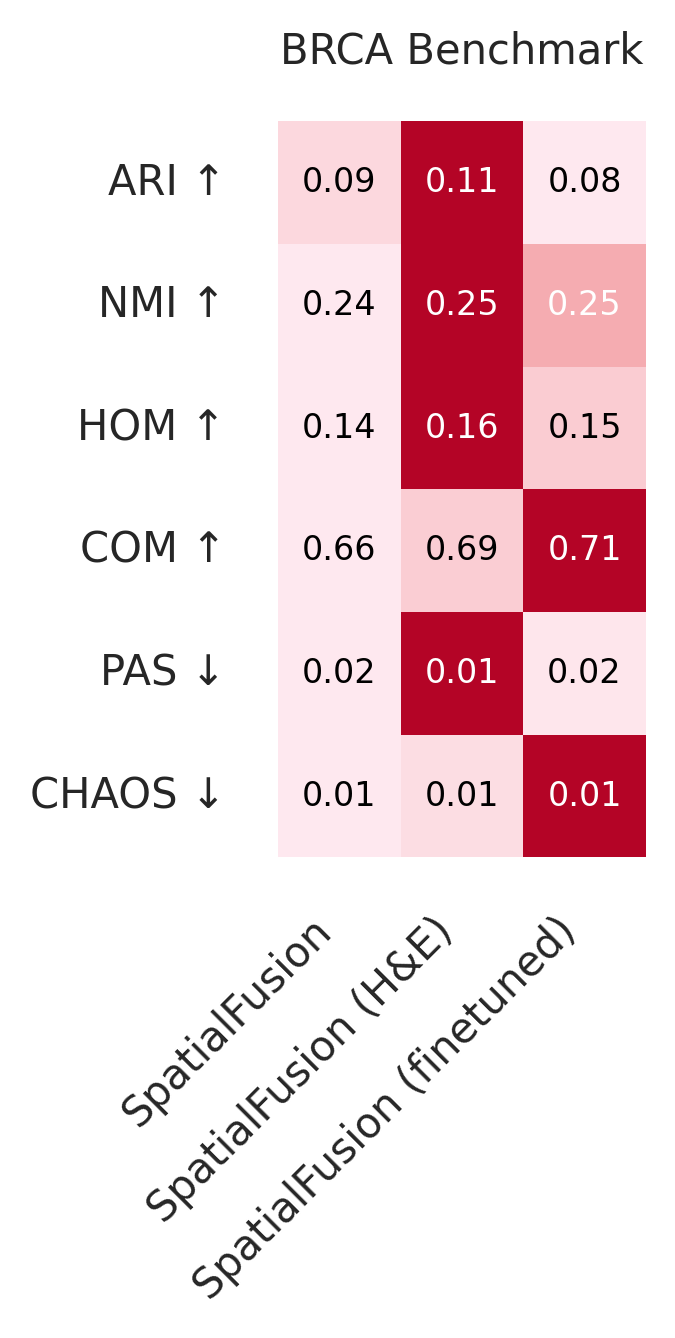

In [ ]:
plot_benchmark_heatmap(results_df, title="OVCA Benchmark")
